## **Getting the data of datasets**

In [11]:
import pandas as pd
titanic=pd.read_csv('drive/MyDrive/Titanic-Dataset.csv')
iris=pd.read_csv('drive/MyDrive/Iris.csv')
print("----------------------csv file is read---------------------------")
print(titanic.head())
print(iris.head())

----------------------csv file is read---------------------------
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123 

## **Initial Inspection**

In [12]:
print("------------------Titanic data inspection")
print(titanic.shape)
print(titanic.info())
print(titanic.describe())
print()
print("---------------------------------------------------------------------")
print("------------------iris data inspection")
print("---------------------------------------------------------------------")
print()
print(iris.shape)
print(iris.info())
print(iris.describe())

------------------Titanic data inspection
(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29

# **Checking number of null values**

In [13]:
print ("==============================titanic==============================")
print(titanic.isnull().sum())
print ("==============================iris==============================")
print(iris.isnull().sum())

==============================titanic==============================
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
==============================iris==============================
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


Iris dataset has no null values....
titanic dataset has 177 null values in age, 687 null values in Cabin and 2 null values in Embarked

# **Treatment of null values**

In [14]:
titanic["Embarked"]=titanic["Embarked"].fillna(
    titanic["Embarked"].mode()[0]
)
titanic["Age"]=titanic["Age"].fillna(
    titanic["Age"].median()
)
titanic["Cabin"]=titanic["Cabin"].fillna("Unknown")
print(titanic.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


Age has outliers. Median is better than mean.
Embarked has categorical value so mode is better.
Cabin has More than 75% values missing. So instead of droping the column the value unknown was added in order to retain useful info

# **Duplicated values and treatment**

In [15]:
print("======================Titanic======================")
print(titanic.duplicated().sum())
print("======================iris======================")
print(iris.duplicated().sum())

======================Titanic======================
0
======================iris======================
0


As there was no duplicated val so no treatment was needed

# **Outlier Detection**

======================Titanic======================



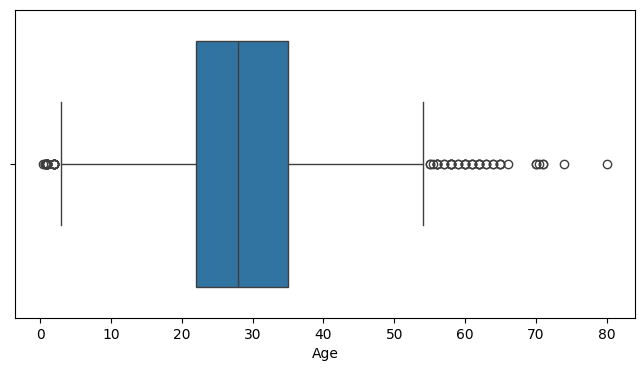

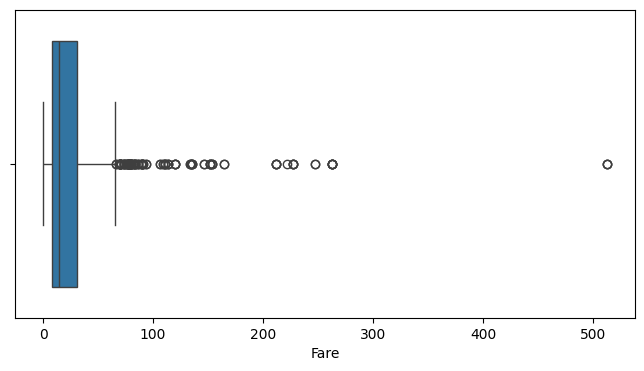


======================Iris======================



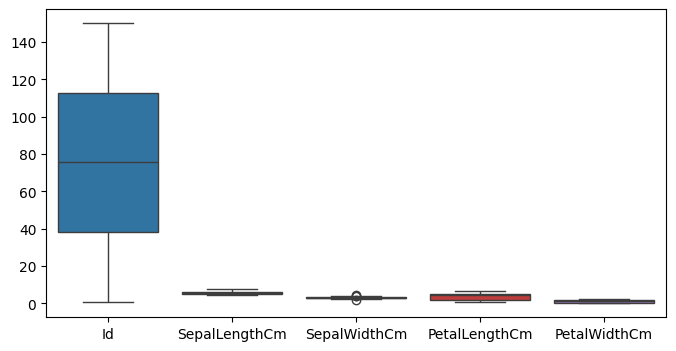

In [16]:
import seaborn as sb
import matplotlib.pyplot as plt
print("======================Titanic======================")
print()
plt.figure(figsize=(8,4))
sb.boxplot(x=titanic["Age"])
plt.show()
plt.figure(figsize=(8,4))
sb.boxplot(x=titanic["Fare"])
plt.show()
print()
print("======================Iris======================")
print()
plt.figure(figsize=(8,4))
sb.boxplot(data=iris)
plt.show()

# **Treatment of outliers**

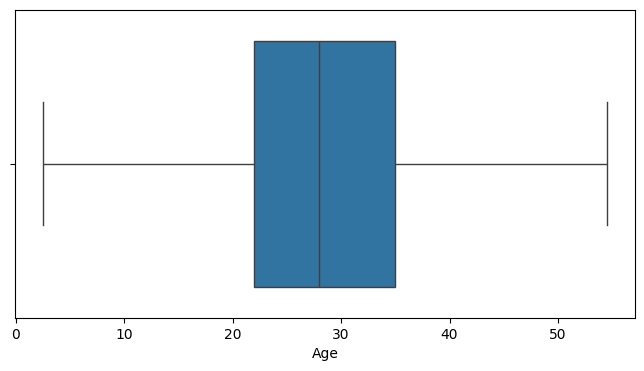

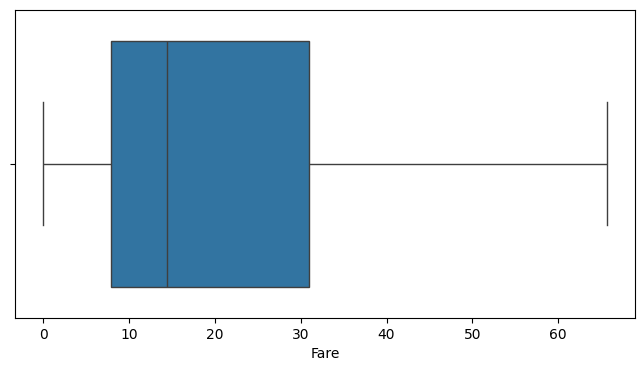

In [17]:
import numpy as np
Q1 = titanic["Fare"].quantile(0.25)
Q3 = titanic["Fare"].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
titanic["Fare"] = np.clip(titanic["Fare"], lower, upper)
Q1 = titanic["Age"].quantile(0.25)
Q3 = titanic["Age"].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
titanic["Age"] = np.clip(titanic["Age"], lower, upper)

plt.figure(figsize=(8,4))
sb.boxplot(x=titanic["Age"])
plt.show()
plt.figure(figsize=(8,4))
sb.boxplot(x=titanic["Fare"])
plt.show()

# **Encoding**

In [18]:
from  sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
titanic["Sex"] = encoder.fit_transform(titanic["Sex"])
titanic=pd.get_dummies(titanic, columns=["Embarked"], drop_first=True)
iris["Species"]=encoder.fit_transform(iris["Species"])
print("-----------------------------------Titanic------------------------------")
print()
print(titanic.head())
print()
print("------------------------------------Iris--------------------------------")
print()
print(iris.head())
print(iris.tail())

-----------------------------------Titanic------------------------------

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare    Cabin  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500  Unknown       False        True  
1          PC 17599  65.6344      C85       False       False  
2  STON/O2. 3101282   7.9250  

# **Standard Scaling**

In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
print("-------------------------Titanic--------------------------------")
columns=["Fare", "Age"]
titanic[columns]=scaler.fit_transform(titanic[columns])
print(titanic.describe())
print()
print("-------------------------IRIS--------------------------------")
columns=iris.columns[1:-1]
iris[columns]=scaler.fit_transform(iris[columns])
print(iris.describe())

-------------------------Titanic--------------------------------
       PassengerId    Survived      Pclass         Sex           Age  \
count   891.000000  891.000000  891.000000  891.000000  8.910000e+02   
mean    446.000000    0.383838    2.308642    0.647587  3.987333e-18   
std     257.353842    0.486592    0.836071    0.477990  1.000562e+00   
min       1.000000    0.000000    1.000000    0.000000 -2.199638e+00   
25%     223.500000    0.000000    2.000000    0.000000 -5.834321e-01   
50%     446.000000    0.000000    3.000000    1.000000 -8.613809e-02   
75%     668.500000    1.000000    3.000000    1.000000  4.940382e-01   
max     891.000000    1.000000    3.000000    1.000000  2.110244e+00   

            SibSp       Parch          Fare  
count  891.000000  891.000000  8.910000e+02  
mean     0.523008    0.381594  7.974666e-18  
std      1.102743    0.806057  1.000562e+00  
min      0.000000    0.000000 -1.174727e+00  
25%      0.000000    0.000000 -7.882908e-01  
50%      0

StandardScaler standardizes numerical features so that they have zero mean and unit variance. Scaling improves the performance of many machine learning algorithms like KNN etc

# **EDA**

-------------------------Titanic--------------------------------



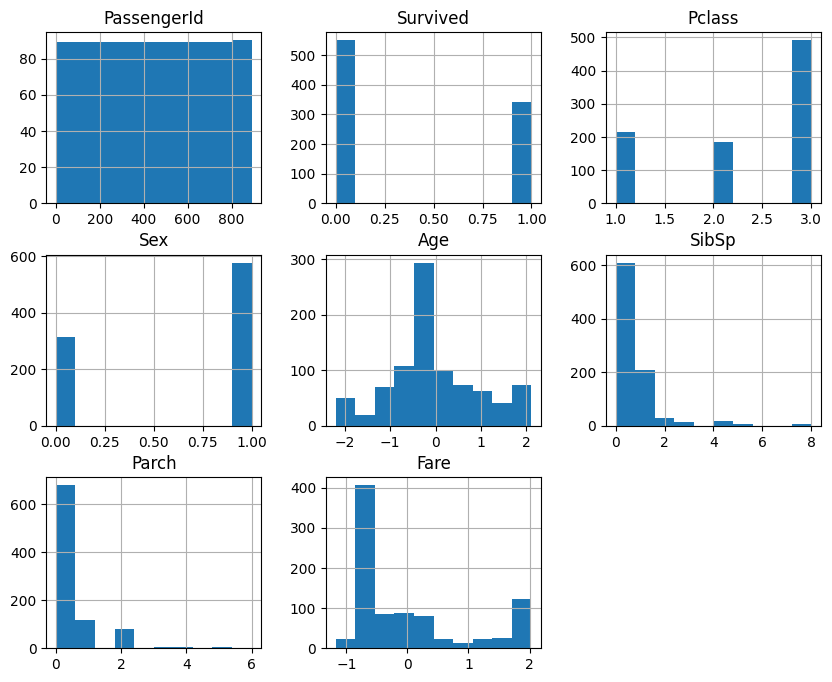

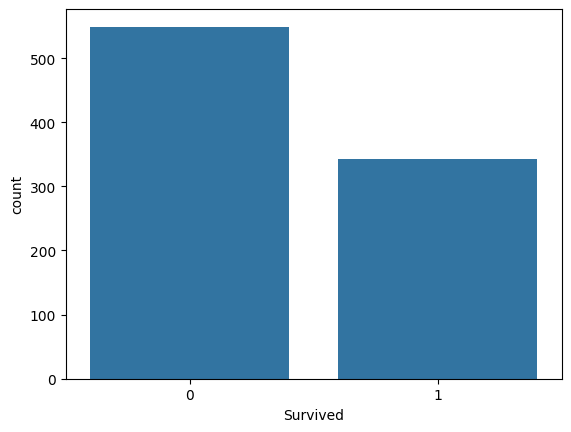

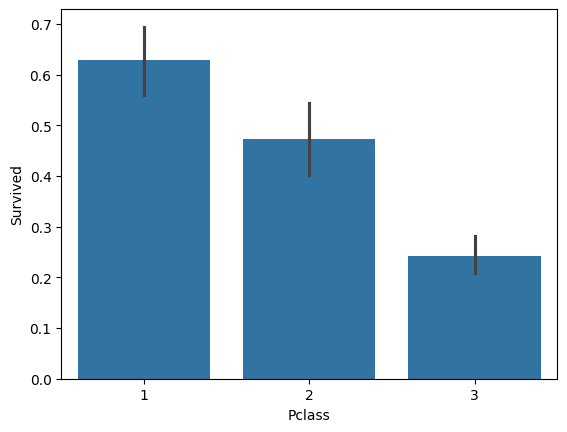

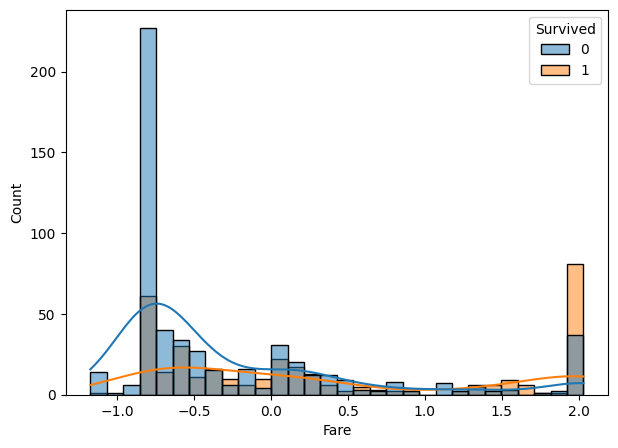

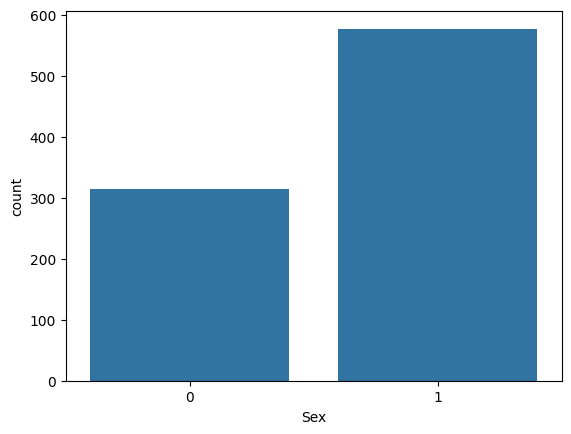

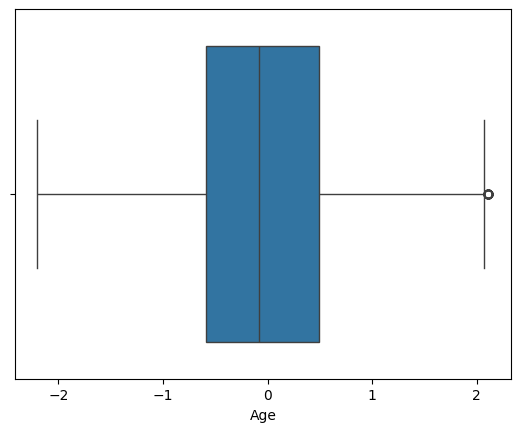

-------------------------Iris--------------------------------


In [29]:
print("-------------------------Titanic--------------------------------")
print()
titanic.hist(figsize=(10,8))
plt.show()
sb.countplot(x="Survived",data=titanic)
plt.show()
sb.countplot(x="Sex", data=titanic)
plt.show()
sb.boxplot(x=titanic["Age"])
plt.show()
print("-------------------------Iris--------------------------------")


# **Bivariate Analysis**

===========================Titanic================================


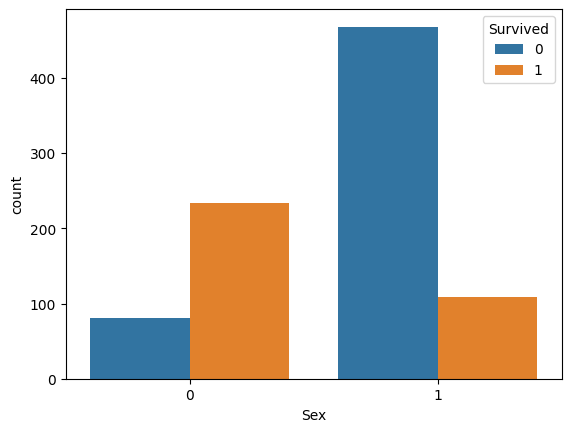

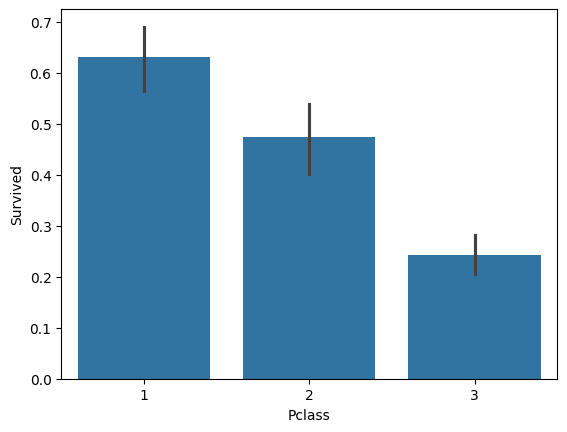

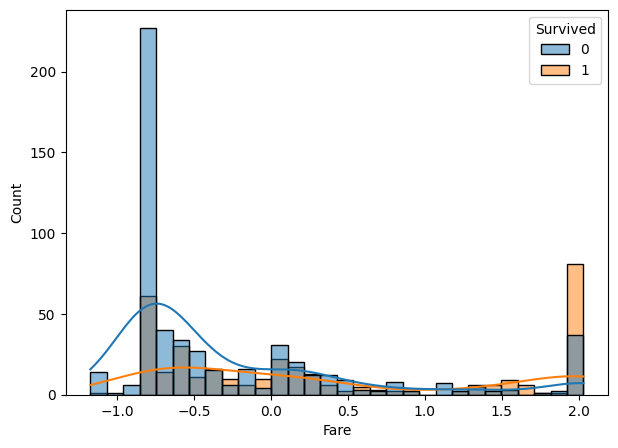



===========================Iris================================




<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

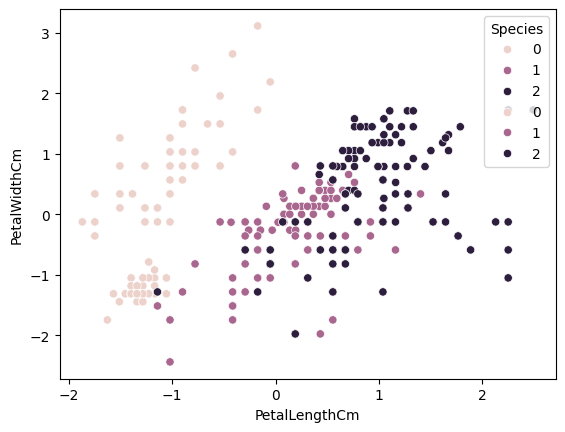

In [32]:
print("===========================Titanic================================")
sb.countplot(x="Sex",
hue="Survived",
data=titanic)
plt.show()
sb.barplot(x="Pclass", y="Survived",data=titanic)
plt.show()
plt.figure(figsize=(7,5))
sb.histplot(
    data=titanic,
    x="Fare",
    hue="Survived",
    bins=30,
    kde=True
)
plt.show()
print()
print()
print("===========================Iris================================")
print()
print()
sb.scatterplot(
x="PetalLengthCm",
y="PetalWidthCm",
hue="Species",
data=iris
)
sb.scatterplot(
x="SepalLengthCm",
y="SepalWidthCm",
hue="Species",
data=iris
)

Female passengers had a higher survival rate.
Those who paid high fare survived more...
Those who use third class survived less...
Petal Length and Petal Width have strong positive correlation

# **Correlation Matrix**

In [35]:
print("=========================Titanic=========================")
corr = titanic.corr(numeric_only=True)
print(corr)
print("=========================Iris===========================")
corr=iris.corr(numeric_only=True)
print(corr)

=========================Titanic=========================
             PassengerId  Survived    Pclass       Sex       Age     SibSp  \
PassengerId     1.000000 -0.005007 -0.035144  0.042939  0.036636 -0.057527   
Survived       -0.005007  1.000000 -0.338481 -0.543351 -0.060622 -0.035322   
Pclass         -0.035144 -0.338481  1.000000  0.131900 -0.340404  0.083081   
Sex             0.042939 -0.543351  0.131900  1.000000  0.074740 -0.114631   
Age             0.036636 -0.060622 -0.340404  0.074740  1.000000 -0.239601   
SibSp          -0.057527 -0.035322  0.083081 -0.114631 -0.239601  1.000000   
Parch          -0.001652  0.081629  0.018443 -0.245489 -0.178959  0.414838   
Fare            0.003243  0.317430 -0.715300 -0.234969  0.144544  0.332021   
Embarked_Q     -0.033606  0.003650  0.221009 -0.074115 -0.035100 -0.026354   
Embarked_S      0.022204 -0.149683  0.074053  0.119224 -0.005078  0.068734   

                Parch      Fare  Embarked_Q  Embarked_S  
PassengerId -0.001652  0.


*   **Titanic**

Most important feature: Sex
Second important feature: Pclass
Third important feature: Fare
Least useful: PassengerId

*   **Iris**

Most important features: Petal Width and PetalLength withSpecies.
Weakest feature: Sepal Width.
Id should be removed because it is only an identifier.

# **Drop Useless Columns for ml algos**

In [36]:
print("====================================Titanic=============================")
print()
print()
titanic.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"],
    inplace=True
)
print (titanic.head())
print()
print()
print("====================================Iris=============================")
print()
print()
iris.drop(
    columns=["Id"],
    inplace=True
)
print (iris.head())

====================================Titanic=============================


   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked_Q  \
0         0       3    1 -0.583432      1      0 -0.820552       False   
1         1       1    0  0.742685      1      0  2.031623       False   
2         1       3    0 -0.251903      0      0 -0.787578       False   
3         1       1    0  0.494038      1      0  1.419297       False   
4         0       3    1  0.494038      0      0 -0.781471       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


====================================Iris=============================


   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0      -0.900681      1.032057      -1.341272     -1.312977        0
1      -1.143017     -0.124958      -1.341272     -1.312977        0
2      -1.385353      0.337848      -1.398138     -1.312977        0
3      -1.506521      0.106445    

# **Saving cleaned CSV**

In [37]:
titanic.to_csv(
    "/content/drive/MyDrive/titanic_cleaned.csv",
    index=False
)
iris.to_csv(
    "/content/drive/MyDrive/iris_cleaned.csv",
    index=False
)

# **Titanic Dataset Summary**

The Titanic dataset was successfully preprocessed by handling missing values, encoding categorical variables, scaling numerical features, and removing unnecessary columns such as PassengerId, Name, Ticket, and Cabin. Exploratory Data Analysis (EDA) revealed that most passengers did not survive, the majority traveled in third class, and the dataset contained more male passengers than female passengers. The Fare feature showed a highly right-skewed distribution with several outliers, while Age was approximately normally distributed. Correlation analysis indicated that Sex had the strongest relationship with survival, followed by Pclass and Fare, whereas PassengerId had almost no predictive value. After preprocessing, the dataset became clean, well-structured, and suitable for training machine learning classification models.

# **Iris Dataset Summary**

The Iris dataset required minimal preprocessing because it contained no missing values. The Id column was removed as it was only an identifier and had no predictive importance. The categorical target variable (Species) was encoded, and numerical features were standardized. EDA showed a strong positive relationship between Petal Length and Petal Width, and scatter plots demonstrated that the three flower species formed distinct clusters, with Setosa being clearly separable from the other two species. Correlation analysis confirmed that Petal Length and Petal Width were the most important features for species classification, while Sepal Width showed the weakest relationship. Overall, the dataset is clean, balanced, and ready for applying machine learning classification algorithms.